# Navier Plate Study

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pyck as ck

The following plate formulations are compared against the full Reissner–Mindlin analytical solution across a wide range of slenderness ratios $L/h$:

| Formulation | DOFs / node | Expected failure |
|---|---|---|
| **KL-1p** (Kirchhoff–Love) | $w$ | Low slenderness — shear neglected |
| **RM-3p** (Reissner–Mindlin, standard) | $w, \varphi_x, \varphi_y$ | High slenderness — shear locking |
| **RM-displ-3p** (split displacement) | $w_b, w_{s1}, w_{s2}$ | Accurate across the full range |
| **RM-displ-1p** (Reissner–Mindlin, rotation-free) | $w_b$ | Accurate across the full range |

In [4]:
FORMULATIONS = {
    "KL-1p": ck.PlateKirchhoffLove1p,
    "RM-3p": ck.PlateReissnerMindlin3p,
    "RM-displ-3p": ck.PlateReissnerMindlinDispl3p,
    "RM-1p": ck.PlateReissnerMindlin1p,
}

## **Reissner-Mindlin Analytical Benchmark**

For a simply-supported plate of dimensions $L \times W$ under load
$q(x,y) = q_0 \sin(\pi x/L)\sin(\pi y/W)$ the exact total deflection is

$$w_\text{total} = \frac{q_0}{K_b\,\lambda^4} + \frac{q_0}{K_s\,\lambda^2},
\qquad \lambda^2 = \left(\frac{\pi}{L}\right)^2 + \left(\frac{\pi}{W}\right)^2$$

The maximum displacement occurs at the plate center:

$$w_\text{max} = \frac{q_0}{K_b\,\lambda^4} + \frac{q_0}{K_s\,\lambda^2}$$

The total strain energy follows from $U = \tfrac{1}{2}\int q\,w\,d\Omega$:

$$U_\text{exact} = \frac{q_0\,w_\text{max}\,L\,W}{8}$$

In [5]:
def sinusoidal_load(L, W, f0):
    """Factory for the sinusoidal load function."""
    def load_fn(pts):
        return f0 * np.sin(np.pi * pts[:, 0] / L) * np.sin(np.pi * pts[:, 1] / W)
    return load_fn

def bending_stiffness(E, nu, h):
    return E * h ** 3 / (12.0 * (1.0 - nu ** 2))

def shear_stiffness(E, nu, h, kappa=5.0 / 6.0):
    shear_modulus = E / (2.0 * (1.0 + nu))
    return kappa * shear_modulus * h

def exact_max_displacement(L, W, f0, E, nu, h, kappa=5.0 / 6.0):
    D = bending_stiffness(E, nu, h)
    Ks = shear_stiffness(E, nu, h, kappa)
    lam2  = (np.pi / L) ** 2 + (np.pi / W) ** 2
    return abs(f0) / (D * lam2 ** 2) + abs(f0) / (Ks * lam2)

def exact_strain_energy(L, W, f0, E, nu, h, kappa=5.0 / 6.0):
    w_max = exact_max_displacement(L, W, f0, E, nu, h, kappa)
    return abs(f0) * w_max * L * W / 8


def exact_displacement_field(L, W, f0, E, nu, h, x, y, kappa=5.0 / 6.0):
    D = bending_stiffness(E, nu, h)
    Ks = shear_stiffness(E, nu, h, kappa)
    lam2 = (np.pi / L) ** 2 + (np.pi / W) ** 2
    amplitude = f0 / (D * lam2 ** 2) + f0 / (Ks * lam2)
    return amplitude * np.sin(np.pi * x / L) * np.sin(np.pi * y / W)


def numerical_max_displacement(surf, element, u, n_eval=41):
    """Recover the maximum displacement from the solution vector."""
    grid = np.linspace(0.0, 1.0, n_eval)
    uu, vv = np.meshgrid(grid, grid, indexing="xy")
    pts_param = np.column_stack([uu.ravel(), vv.ravel()])
    shape = ck.eval_shape_at(surf, pts_param, order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    w = Nw @ u
    return np.max(np.abs(w))

def physical_solution(surf, element, u):
    n_phys = surf.num_control_pts * element._cpp_object.num_node_dofs()
    return np.asarray(u)[:n_phys]


def evaluate_displacement(surf, element, u, pts_param):
    """Evaluate the transverse displacement at parametric points."""
    shape = ck.eval_shape_at(surf, pts_param, order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    return np.asarray(Nw @ u).reshape(-1)


def sample_boundary(side: str, npts: int):
    s = np.linspace(0.0, 1.0, npts)
    if side == "u0":
        return np.column_stack([np.zeros_like(s), s]), s, "y"
    if side == "u1":
        return np.column_stack([np.ones_like(s), s]), s, "y"
    if side == "v0":
        return np.column_stack([s, np.zeros_like(s)]), s, "x"
    if side == "v1":
        return np.column_stack([s, np.ones_like(s)]), s, "x"
    raise ValueError(f"Unknown boundary side: {side}")


def sample_centerline(npts: int):
    s = np.linspace(0.0, 1.0, npts)
    return np.column_stack([s, 0.5 * np.ones_like(s)]), s, "x"



## **Lagrange Multipliers**

The Lagrange Multiplier functional is defined by introducing multiplier fields to enforce the constraints:

$$
\Pi^{\mathrm{LM}} = \int_{\Gamma} \lambda_w (w - \bar{w}) \, d\Gamma + \int_{\Gamma} \boldsymbol{\lambda}_{\varphi} \cdot (\boldsymbol{\varphi} - \bar{\boldsymbol{\varphi}}) \, d\Gamma
$$

Taking the variation with respect to both the state variables ($w, \boldsymbol{\varphi}$) and the multipliers ($\lambda_w, \boldsymbol{\lambda}_{\varphi}$) leads to the following system of equations:

$$
\delta \Pi^{\mathrm{LM}} = \int_{\Gamma} (\delta \lambda_w w + \lambda_w \delta w) \, d\Gamma + \int_{\Gamma} (\delta \boldsymbol{\lambda}_{\varphi} \cdot \boldsymbol{\varphi} + \boldsymbol{\lambda}_{\varphi} \cdot \delta \boldsymbol{\varphi}) \, d\Gamma = 0
$$

After discretization, this yields the augmented saddle-point system:

$$
\begin{bmatrix}
\mathbf{K} & \mathbf{C}^T \\
\mathbf{C} & \mathbf{0}
\end{bmatrix}
\begin{bmatrix}
\mathbf{u} \\
\boldsymbol{\lambda}
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{f} \\
\mathbf{g}
\end{bmatrix}
$$

The coupling matrix $\mathbf{C}$ represents the interaction between the boundary shape functions and the multiplier shape functions:

$$
\mathbf{C} = \int_{\Gamma} \begin{bmatrix} N_{\lambda_w}^T N_w \\ N_{\lambda_{\varphi}}^T N_{\varphi} \end{bmatrix} d\Gamma
$$

In [6]:
def apply_ss_lagrange(
    problem: ck.LinearElasticProblem,
    patch: ck.SurfacePatch,
    element,
    quadrature: ck.QuadratureRule,
):
    """Apply simply supported boundary conditions via Lagrange multipliers."""
    for side in ("u0", "u1", "v0", "v1"):
        bd = patch.boundary(side)
        cond = ck.LagrangeMultiplierCondition(
            bd, element, quadrature,
            w_bar=0.0,
            phi_s_bar=0.0,
        )
        problem.add_condition(cond)

## Problem 

In [7]:
def solve_plate_case(
    L: float, W: float, h: float, f0: float, formulation: str
) -> dict:
    # Constitutive law
    mat = ck.PlaneStress2d(E, nu, h)

    # Patch genometry
    bu = ck.create_clamped_uniform(p, n)
    bv = ck.create_clamped_uniform(p, n)
    patch = ck.create_rectangle(bu, bv, L, W)

    # Quadrature rules for surface and boundary integration
    gauss2d = ck.create_gauss_from_patch(patch)
    gauss1d = ck.GaussLegendre(p + 1, dim=1)

    # Load function
    load_fn = sinusoidal_load(L, W, f0)

    # Element formulation
    element_cls = FORMULATIONS[formulation]
    element = element_cls(mat)

    # Define linear elastic problem
    prob = ck.create_linear_elastic_problem([patch], element, gauss2d)

    # Apply loads and boundary conditions, assemble system
    prob.add_condition(ck.create_function_load_condition(patch, load_fn, gauss2d))
    apply_ss_lagrange(prob, patch, element, gauss1d)
    K, f = prob.assemble()

    # Solve
    u_full = ck.solve(K, f)
    u = physical_solution(patch, element, u_full)

    # Postprocessing: max displacement and strain energy
    w = numerical_max_displacement(patch, element, u)
    U = 0.5 * f[:u.size] @ u

    return {
        "patch": patch,
        "element": element,
        "u": u,
        "w": w,
        "U": U,
    }

In [8]:
# Plate geometry
L = 1.0
W = 1.0
slenderness = np.logspace(np.log10(5.0), 6.0, 15)

# Load
f0 = -10.0

# Plate material parameters
E = 1.0e7
nu = 0.3

# Numerical parameters
p = 3
n = 12

s_history = []
U_exact_history = []
w_exact_history = []
U_history = {name: [] for name in FORMULATIONS}
w_history = {name: [] for name in FORMULATIONS}

print("Simply-supported Navier plate with Lagrange-multiplier BCs")
print(
    f"{'L/h':>10} | {'KL U%':>7} | {'KL w%':>7} | "
    f"{'RM3 U%':>8} | {'RM3 w%':>8} | "
    f"{'RMD3 U%':>9} | {'RMD3 w%':>9} | "
    f"{'RM1 U%':>8} | {'RM1 w%':>8}"
)
print("-" * 104)

for slenderness_value in slenderness:
    # Analytical benchmarks
    h = L / slenderness_value
    U_exact = exact_strain_energy(L, W, f0, E, nu, h)
    w_exact = exact_max_displacement(L, W, f0, E, nu, h)

    # Store results
    s_history.append(slenderness_value)
    U_exact_history.append(U_exact)
    w_exact_history.append(w_exact)
    error_history = {}

    # Solve for each formulation
    for formulation in FORMULATIONS:
        results = solve_plate_case(L, W, h, f0, formulation)

        U_history[formulation].append(results["U"])
        w_history[formulation].append(results["w"])

        error_history[formulation] = (
            abs(results["U"] - U_exact) / U_exact * 100.0,
            abs(results["w"] - w_exact) / w_exact * 100.0,
        )

    print(
        f"{slenderness_value:10.1f} | "
        f"{error_history['KL-1p'][0]:6.2f}% | {error_history['KL-1p'][1]:6.2f}% | "
        f"{error_history['RM-3p'][0]:7.2f}% | {error_history['RM-3p'][1]:7.2f}% | "
        f"{error_history['RM-displ-3p'][0]:8.2f}% | {error_history['RM-displ-3p'][1]:8.2f}% | "
        f"{error_history['RM-1p'][0]:7.2f}% | {error_history['RM-1p'][1]:7.2f}%"
    )

Simply-supported Navier plate with Lagrange-multiplier BCs
       L/h |   KL U% |   KL w% |   RM3 U% |   RM3 w% |   RMD3 U% |   RMD3 w% |   RM1 U% |   RM1 w%
--------------------------------------------------------------------------------------------------------
       5.0 |  18.41% |  18.41% |    0.00% |    0.00% |     0.00% |     0.00% |    0.05% |    0.15%
      12.0 |   3.80% |   3.80% |    0.00% |    0.00% |     0.00% |     0.00% |    0.01% |    0.03%
      28.6 |   0.69% |   0.69% |    0.00% |    0.00% |     0.00% |     0.00% |    0.00% |    0.01%
      68.4 |   0.12% |   0.13% |    0.01% |    0.01% |     0.00% |     0.00% |    0.00% |    0.01%
     163.5 |   0.02% |   0.03% |    0.03% |    0.04% |     0.00% |     0.00% |    0.00% |    0.00%
     391.0 |   0.00% |   0.01% |    0.17% |    0.23% |     0.00% |     0.00% |    0.00% |    0.00%
     935.1 |   0.00% |   0.01% |    0.92% |    1.31% |     0.00% |     0.00% |    0.00% |    0.00%
    2236.1 |   0.00% |   0.00% |    3.83% | 

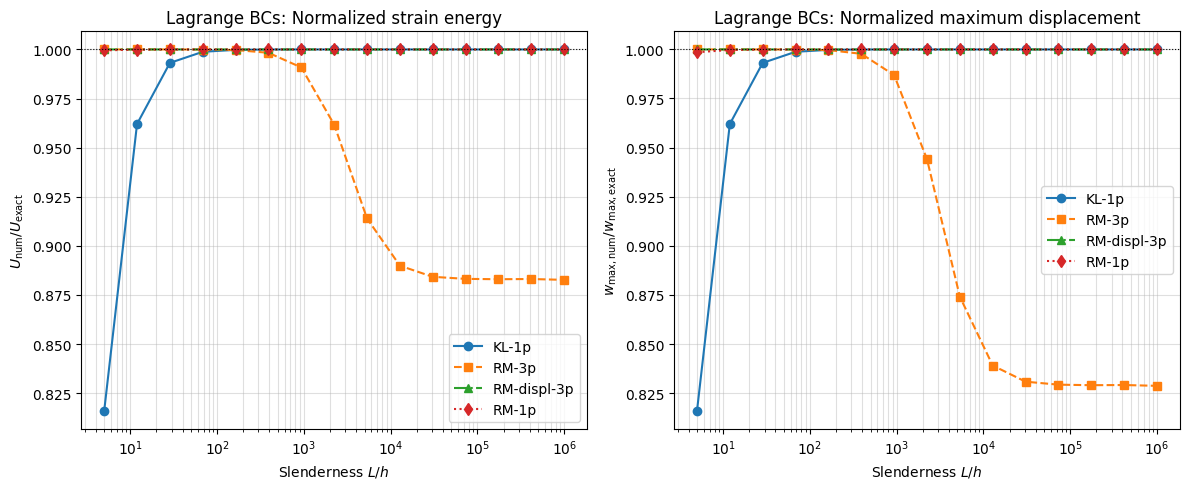

In [9]:
s_history = np.asarray(s_history)
U_exact_history = np.asarray(U_exact_history)
w_exact_history = np.asarray(w_exact_history)

for formulation in FORMULATIONS:
    U_history[formulation] = np.asarray(U_history[formulation])
    w_history[formulation] = np.asarray(w_history[formulation])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

styles = {
    "KL-1p": "o-",
    "RM-3p": "s--",
    "RM-displ-3p": "^-.",
    "RM-1p": "d:",
}

for formulation in FORMULATIONS:
    ax1.plot(
        s_history,
        U_history[formulation] / U_exact_history,
        styles[formulation],
        label=formulation,
    )
ax1.axhline(1.0, color="k", lw=0.8, ls=":")
ax1.set_xscale("log")
ax1.set_xlabel("Slenderness $L/h$")
ax1.set_ylabel(r"$U_\mathrm{num} / U_\mathrm{exact}$")
ax1.set_title("Lagrange BCs: Normalized strain energy")
ax1.legend()
ax1.grid(True, which="both", alpha=0.4)

for formulation in FORMULATIONS:
    ax2.plot(
        s_history,
        w_history[formulation] / w_exact_history,
        styles[formulation],
        label=formulation,
    )
ax2.axhline(1.0, color="k", lw=0.8, ls=":")
ax2.set_xscale("log")
ax2.set_xlabel("Slenderness $L/h$")
ax2.set_ylabel(r"$w_{\max,\mathrm{num}} / w_{\max,\mathrm{exact}}$")
ax2.set_title("Lagrange BCs: Normalized maximum displacement")
ax2.legend()
ax2.grid(True, which="both", alpha=0.4)

fig.tight_layout()
plt.show()

## Boundary and Midline Profiles

For a representative thick plate ($L/h=5$), inspect:

- the boundary displacement on one edge, where the weak Lagrange enforcement may introduce small oscillations around the exact zero trace
- the centerline profile, which can be compared directly with the analytical sinusoidal displacement field

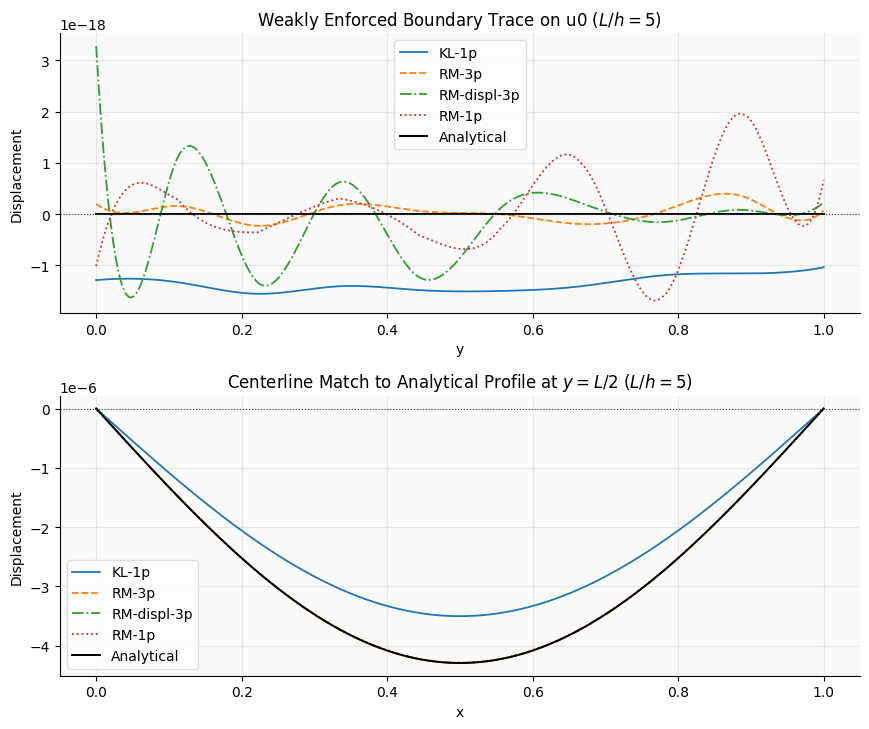

In [10]:
PROFILE = {
    "slenderness": 5.0,
    "boundary_side": "u0",
    "points": 1001,
}

profile_styles = {
    "KL-1p": {"color": "tab:blue", "ls": "-", "lw": 1.3},
    "RM-3p": {"color": "tab:orange", "ls": "--", "lw": 1.3},
    "RM-displ-3p": {"color": "tab:green", "ls": "-.", "lw": 1.3},
    "RM-1p": {"color": "tab:red", "ls": ":", "lw": 1.3},
}

h_profile = L / PROFILE["slenderness"]
pts_boundary_param, boundary_coord, boundary_xlabel = sample_boundary(
    PROFILE["boundary_side"], PROFILE["points"]
)
pts_mid_param, mid_coord, mid_xlabel = sample_centerline(PROFILE["points"])

profile_results = {}
for formulation in FORMULATIONS:
    profile_results[formulation] = solve_plate_case(
        L, W, h_profile, f0, formulation
    )

pts_boundary_phys = ck.eval_geometry_at(profile_results["KL-1p"]["patch"], pts_boundary_param)
pts_mid_phys = ck.eval_geometry_at(profile_results["KL-1p"]["patch"], pts_mid_param)

w_boundary_exact = exact_displacement_field(
    L, W, f0, E, nu, h_profile, pts_boundary_phys[:, 0], pts_boundary_phys[:, 1]
)
w_mid_exact = exact_displacement_field(
    L, W, f0, E, nu, h_profile, pts_mid_phys[:, 0], pts_mid_phys[:, 1]
)

fig_profiles, (ax3, ax4) = plt.subplots(2, 1, figsize=(8.8, 7.4), sharex=False)

for formulation in FORMULATIONS:
    case = profile_results[formulation]
    ax3.plot(
        boundary_coord,
        evaluate_displacement(case["patch"], case["element"], case["u"], pts_boundary_param),
        **profile_styles[formulation],
        label=formulation,
    )
ax3.plot(boundary_coord, w_boundary_exact, color="k", ls="-", lw=1.4, label="Analytical")
ax3.axhline(0.0, color="0.25", lw=0.8, ls=":")
ax3.set_xlabel(boundary_xlabel)
ax3.set_ylabel("Displacement")
ax3.set_title(
    f"Weakly Enforced Boundary Trace on {PROFILE['boundary_side']} ($L/h = {PROFILE['slenderness']:.0f}$)"
)
ax3.legend(frameon=True, facecolor="white", edgecolor="0.85")
ax3.grid(True, alpha=0.25)

for formulation in FORMULATIONS:
    case = profile_results[formulation]
    ax4.plot(
        mid_coord,
        evaluate_displacement(case["patch"], case["element"], case["u"], pts_mid_param),
        **profile_styles[formulation],
        label=formulation,
    )
ax4.plot(mid_coord, w_mid_exact, color="k", ls="-", lw=1.4, label="Analytical")
ax4.axhline(0.0, color="0.25", lw=0.8, ls=":")
ax4.set_xlabel(mid_xlabel)
ax4.set_ylabel("Displacement")
ax4.set_title(
    f"Centerline Match to Analytical Profile at $y=L/2$ ($L/h = {PROFILE['slenderness']:.0f}$)"
)
ax4.legend(frameon=True, facecolor="white", edgecolor="0.85")
ax4.grid(True, alpha=0.25)

for ax in (ax3, ax4):
    ax.set_facecolor("#fafafa")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig_profiles.tight_layout()
plt.show()